# 02 - Modeli i metode

**Tema 28 - Simulacija autonomnog vozila (Unity ML-Agents)**

Notebook 01 je bio o **datasetu**. Ovaj je o **modelima**: kako nastaje staza, kako skriptirani
vozač odlučuje, kako uči PPO agent, i čime se na kraju sve to poredi.

Kao i 01, ide **korak po korak**, i uz svaku ćeliju stoji *šta* radimo i *zašto*. Razlika je u
tome što ovdje ništa ne treniramo: sve što se pokreće je već implementirano u paketima
`python/track`, `python/eda` i `python/m5`, a ovaj notebook to **poziva i crta**, ne
reimplementira.

**Zašto to tako:** ako bi notebook imao svoju kopiju formule, ta kopija bi se s vremenom
razišla od one koja stvarno generiše staze, i grafovi bi počeli opisivati kod koji ne postoji.

## Šta ćemo proći

| Sekcija | Pitanje na koje odgovara |
|---|---|
| 1 | Kako se staza generiše iz jednog cijelog broja |
| 2 | Zašto je prag najoštrije krivine 6.97 m, a ne neki drugi broj |
| 3 | Kako skriptirani vozač bira volan, i zašto naivna verzija ne može proći krug |
| 4 | Šta PPO uči i kako se to vidi na krivama treninga |
| 5 | Kojim testovima se poredi RL, BC, skripta i čovjek |

## Mali pojmovnik

- **seed** - jedan cijeli broj iz kojeg se determinististički izvodi cijela staza.
- **harmonik** - jedan sinusni član u sumi koja opisuje oblik staze.
- **zakrivljenost** ($\kappa$) - koliko kriva skreće u datoj tački; poluprečnik je $1/|\kappa|$.
- **bicikl-model** - pojednostavljenje vozila na dva točka, iz kojeg slijedi $R = L / \tan\delta$.
- **zraka (raycast)** - mjerenje udaljenosti do prve prepreke u jednom smjeru.
- **politika** - funkcija koja iz observacije daje akciju. Kod PPO-a je to neuronska mreža.
- **on-policy** - uči se iz podataka koje je proizvela trenutna politika, ne iz arhive.
- **KL divergencija** - koliko se jedna raspodjela razlikuje od druge, u nats-ima.

## Priprema

Isti obrazac kao u notebooku 01: nalazimo korijen repozitorija da uvozi rade bez obzira odakle
je notebook pokrenut, pa uvozimo **stvarne** module projekta.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
REPO_ROOT = next(p for p in [_here, *_here.parents] if (p / "python" / "track").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from python.track import config as track_config
from python.track import generator, geometry, matching
from python.track.vehicle import build_profile, radius_for_steering

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PROFILE = build_profile()
print("korijen repozitorija:", REPO_ROOT)
print("profil vozila:", PROFILE)

korijen repozitorija: C:\Users\User\Development\RMS
profil vozila: VehicleProfile(wheelbase_m=2.5, steer_max_deg=25.0, steer_rate_norm_per_s=3.7, v_max_ms=10.0, accel_ms2=5.0, brake_ms2=5.85, radius_margin=1.3)


# Sekcija 1 - Kako nastaje staza

Staze se ne crtaju rukom. Svaka je izvedena iz **jednog cijelog broja**, i isti broj uvijek daje
isti fajl, bajt po bajt. To nije udobnost nego uslov: staza koja se ne može ponovo proizvesti nije
podatak, nego slika.

Oblik je **polarna harmonijska petlja**:

$$
r(\theta) = R_0 \left(1 + \sum_k a_k \sin(k\theta + \phi_k)\right),
\qquad
a_k = \frac{A}{k^2}.
$$

Čitano riječima: krećemo od kruga poluprečnika $R_0$, pa ga **talasamo** zbirom sinusa. Svaki
sinus $k$ napravi $k$ izbočina po punom krugu.

Tri stvari dolaze iz seed-a, i ništa drugo:

In [2]:
print("R0 (osnovni poluprečnik) =", track_config.TRACK_R0_M, "m")
print("harmonici k              =", track_config.HARMONICS)
print("opseg amplitude A        =", track_config.AMPLITUDE_RANGE)
print("uzoraka po stazi         =", track_config.SAMPLES_PER_TRACK)

R0 (osnovni poluprečnik) = 30.0 m
harmonici k              = (2, 3, 4, 5)
opseg amplitude A        = (0.7, 0.9)
uzoraka po stazi         = 2000


## 1.1 Zašto amplituda pada kao $1/k^2$

Da su svi harmonici jednako jaki, oni sa visokim $k$ bi napravili puno sitnih izbočina i staza bi
postala nazubljena. Faktor $a_k = A/k^2$ svakom sljedećem harmoniku daje sve manje uticaja.

Nacrtajmo pojedinačne članove za jedan seed, pa njihov zbir.

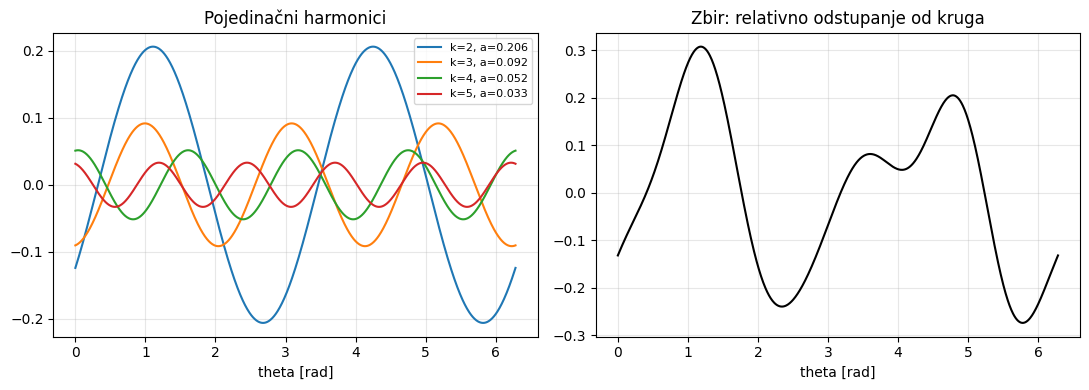

A iz seed-a: 0.825
amplitude po harmoniku: {2: 0.2063, 3: 0.0917, 4: 0.0516, 5: 0.033}


In [3]:
SEED = 7
params = generator.draw_parameters(SEED)
HARMONICS = track_config.HARMONICS
AMPS = [params.amplitude / (k * k) for k in HARMONICS]
theta = np.linspace(0, 2 * np.pi, 1000)

fig, ax = plt.subplots(1, 2)

# Lijevo: svaki harmonik zasebno, u istoj skali.
for k, a, phi in zip(HARMONICS, AMPS, params.phases):
    ax[0].plot(theta, a * np.sin(k * theta + phi), label=f"k={k}, a={a:.3f}")
ax[0].set_title("Pojedinačni harmonici")
ax[0].set_xlabel("theta [rad]")
ax[0].legend(fontsize=8)

# Desno: njihov zbir, koji je odstupanje od kruga.
total = sum(a * np.sin(k * theta + phi)
            for k, a, phi in zip(HARMONICS, AMPS, params.phases))
ax[1].plot(theta, total, color="black")
ax[1].set_title("Zbir: relativno odstupanje od kruga")
ax[1].set_xlabel("theta [rad]")

plt.tight_layout()
plt.show()

print("A iz seed-a:", round(params.amplitude, 4))
print("amplitude po harmoniku:", dict(zip(HARMONICS, np.round(AMPS, 4))))

Vidi se pad: prvi harmonik nosi najviše, zadnji jedva. To je $1/k^2$ na djelu.

## 1.2 Staza kao kriva

Sada isto to u polarnim koordinatama, što je ustvari staza.

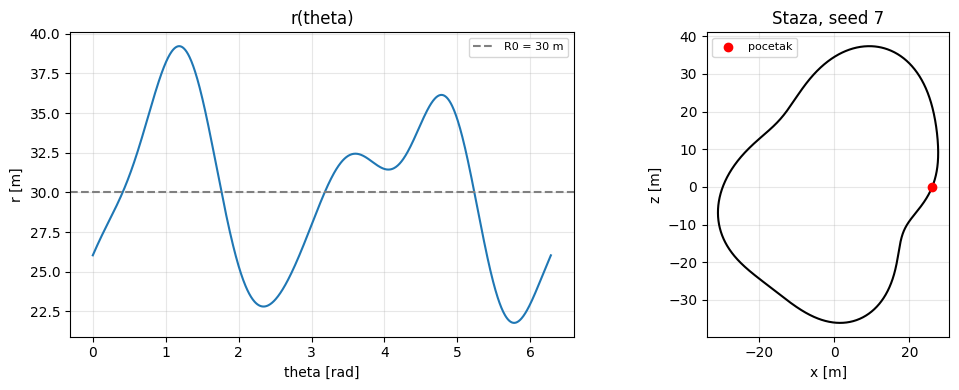

dužina staze: 202.4 m


In [4]:
line = generator.generate(SEED)

fig, ax = plt.subplots(1, 2)

ax[0].plot(theta, track_config.TRACK_R0_M * (1 + total))
ax[0].axhline(track_config.TRACK_R0_M, color="gray", linestyle="--", label="R0 = 30 m")
ax[0].set_title("r(theta)")
ax[0].set_xlabel("theta [rad]")
ax[0].set_ylabel("r [m]")
ax[0].legend(fontsize=8)

ax[1].plot(line.x, line.y, color="black")
ax[1].scatter([line.x[0]], [line.y[0]], color="red", zorder=5, label="pocetak")
ax[1].set_aspect("equal")
ax[1].set_title(f"Staza, seed {SEED}")
ax[1].set_xlabel("x [m]")
ax[1].set_ylabel("z [m]")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"dužina staze: {line.total_length_m:.1f} m")

## 1.3 Zašto se petlja zatvara sama od sebe

Svaki harmonik je **cijeli** umnožak od $\theta$, pa nakon punog kruga svaki sinus završi tamo
gdje je počeo. Kraj se poklopi sa početkom bez ijedne korekcije.

To nije estetika. Kad bi se krajevi "šili" naknadno, na šavu bi nastao **skok u zakrivljenosti**,
a to vozilo osjeti kao trzaj volana na jednom te istom mjestu svakog kruga. Provjerimo da se
zaista poklapa:

In [5]:
r0 = track_config.TRACK_R0_M * (1 + sum(
    a * np.sin(k * 0.0 + phi) for k, a, phi in zip(HARMONICS, AMPS, params.phases)))
r2pi = track_config.TRACK_R0_M * (1 + sum(
    a * np.sin(k * 2 * np.pi + phi) for k, a, phi in zip(HARMONICS, AMPS, params.phases)))

print(f"r(0)    = {r0:.12f} m")
print(f"r(2*pi) = {r2pi:.12f} m")
print(f"razlika = {abs(r0 - r2pi):.2e} m   (nula do numeričke preciznosti)")

r(0)    = 26.031021839721 m
r(2*pi) = 26.031021839721 m
razlika = 7.11e-15 m   (nula do numeričke preciznosti)


## 1.4 Zakrivljenost u zatvorenoj formi

Pošto su $r$, $r'$ i $r''$ opet sume sinusa, zakrivljenost se dobija **formulom, ne numeričkom
derivacijom**:

$$
\kappa(\theta) = \frac{r^2 + 2r'^2 - r\,r''}{\left(r^2 + r'^2\right)^{3/2}},
\qquad
R(\theta) = \frac{1}{|\kappa(\theta)|}.
$$

Zašto je to bitno: numerička derivacija je najnepouzdanija tačno tamo gdje nam najviše treba, u
najoštrijoj krivini. Odluka o prihvatanju staze se donosi na osnovu **najmanjeg** poluprečnika,
pa greška baš na tom mjestu bi značila da prihvatamo staze koje ne bismo smjeli.

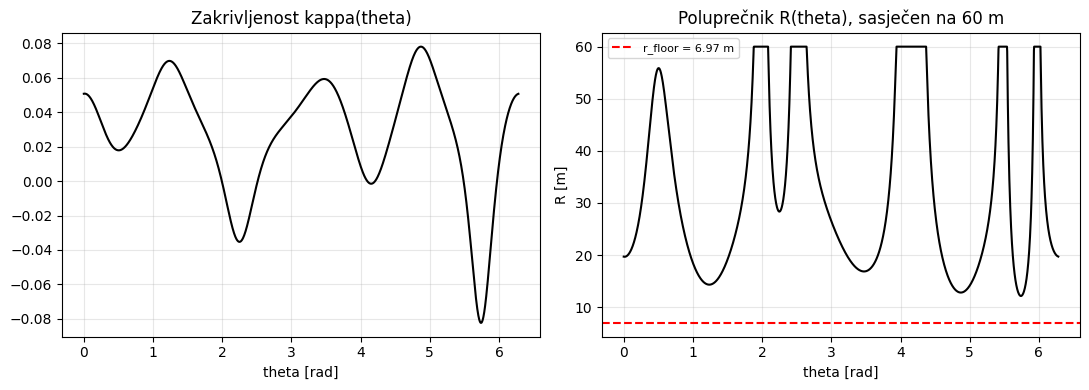

najoštrija krivina na ovoj stazi: 12.14 m


In [6]:
fig, ax = plt.subplots(1, 2)

ax[0].plot(line.theta, line.curvature, color="black")
ax[0].set_title("Zakrivljenost kappa(theta)")
ax[0].set_xlabel("theta [rad]")

# Poluprečnik je 1/|kappa| i u prevojima ide u beskonačno, pa ga sasjecamo radi čitljivosti.
ax[1].plot(line.theta, np.minimum(line.radius, 60), color="black")
ax[1].axhline(PROFILE.r_floor_m, color="red", linestyle="--",
              label=f"r_floor = {PROFILE.r_floor_m:.2f} m")
ax[1].set_title("Poluprečnik R(theta), sasječen na 60 m")
ax[1].set_xlabel("theta [rad]")
ax[1].set_ylabel("R [m]")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"najoštrija krivina na ovoj stazi: {line.radius.min():.2f} m")

# Sekcija 2 - Odakle prag od 6.97 m

Prag najoštrije krivine nije odabran nego **izveden**. Bicikl-model kaže da vozilo pri malim
brzinama i punom zaokretu opisuje krug poluprečnika

$$
R_{\min} = \frac{L}{\tan \delta_{\max}},
$$

gdje je $L$ međuosovinsko rastojanje a $\delta_{\max}$ maksimalni ugao prednjih točkova. Na taj
broj se dodaje **margina**, jer staza koja traži tačno puni zaokret ne ostavlja vozaču ništa.

In [7]:
import math

L = PROFILE.wheelbase_m
delta = PROFILE.steer_max_rad
m = PROFILE.radius_margin

print(f"L (medjuosovinsko)   = {L} m")
print(f"delta_max            = {PROFILE.steer_max_deg} deg")
print(f"margina m            = {m}")
print()
print(f"R_min    = L / tan(delta_max) = {L} / {math.tan(delta):.4f} = {PROFILE.r_min_m:.3f} m")
print(f"r_floor  = m * R_min          = {m} * {PROFILE.r_min_m:.3f} = {PROFILE.r_floor_m:.3f} m")

L (medjuosovinsko)   = 2.5 m
delta_max            = 25.0 deg
margina m            = 1.3

R_min    = L / tan(delta_max) = 2.5 / 0.4663 = 5.361 m
r_floor  = m * R_min          = 1.3 * 5.361 = 6.970 m


## 2.1 Koliko volana staza traži

Isti model, obrnut, kaže koliko volana je potrebno u tački poluprečnika $R$:

$$
s_{\text{req}} = \frac{\arctan(L / R)}{\delta_{\max}} \in [0, 1].
$$

Zanimljiva posljedica: na samom pragu ta vrijednost **ne zavisi od $L$**, jer se $L$ skrati.
Margina je jedini parametar koji je pomjera, što je čini poštenom ručkom.

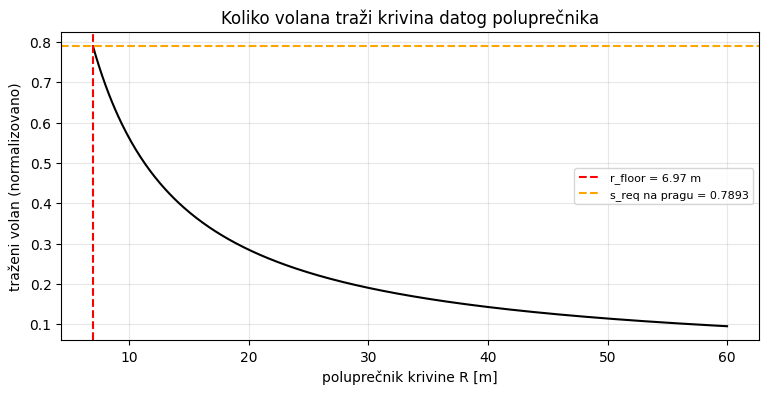

L = 2.0 m  ->  R_min =  4.29 m, r_floor =  5.58 m, s_req na pragu = 0.789313
L = 2.5 m  ->  R_min =  5.36 m, r_floor =  6.97 m, s_req na pragu = 0.789313
L = 3.2 m  ->  R_min =  6.86 m, r_floor =  8.92 m, s_req na pragu = 0.789313


In [8]:
radii = np.linspace(PROFILE.r_floor_m, 60, 400)
required = np.arctan(L / radii) / delta

plt.figure(figsize=(9, 4))
plt.plot(radii, required, color="black")
plt.axvline(PROFILE.r_floor_m, color="red", linestyle="--", label=f"r_floor = {PROFILE.r_floor_m:.2f} m")
plt.axhline(PROFILE.max_required_steer, color="orange", linestyle="--",
            label=f"s_req na pragu = {PROFILE.max_required_steer:.4f}")
plt.xlabel("poluprečnik krivine R [m]")
plt.ylabel("traženi volan (normalizovano)")
plt.title("Koliko volana traži krivina datog poluprečnika")
plt.legend(fontsize=8)
plt.show()

# Dokaz da L nema uticaja: mijenja se medjuosovinsko rastojanje, broj ostaje isti.
import dataclasses
for test_L in (2.0, 2.5, 3.2):
    prof = dataclasses.replace(PROFILE, wheelbase_m=test_L)
    print(f"L = {test_L} m  ->  R_min = {prof.r_min_m:5.2f} m, "
          f"r_floor = {prof.r_floor_m:5.2f} m, "
          f"s_req na pragu = {prof.max_required_steer:.6f}")

## 2.2 Prihvaćen i odbijen seed

Generator ne uzorkuje dok ne uspije. Seed koji padne se **zapisuje sa razlogom** i nikad se ne
pokušava ponovo sa podešenim parametrima. Razlog je metodološki: generator koji tiho ponavlja ima
stopu prihvatanja koju niko ne vidi, a ta stopa je sama po sebi nalaz.

Pogledajmo jedan prihvaćen i jedan odbijen seed jedan pored drugog.

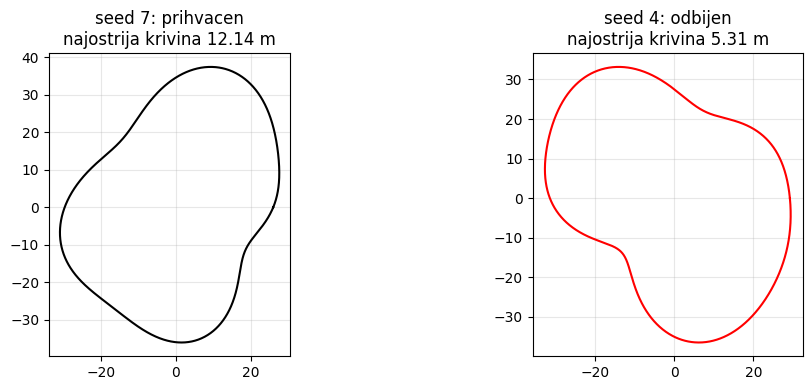

seed 7: prihvacen=True  razlog=None


seed 4: prihvacen=False  razlog=tightest corner 5.31 m is below the floor 6.97 m


In [9]:
ACCEPTED, REJECTED = 7, 4   # seed 4 pada na pragu poluprečnika, vidi results/tracks/batch_report.md

fig, ax = plt.subplots(1, 2)
for axis, seed in zip(ax, (ACCEPTED, REJECTED)):
    l = generator.generate(seed)
    report = geometry.check_geometry(l, PROFILE)
    axis.plot(l.x, l.y, color="black" if report.ok else "red")
    axis.set_aspect("equal")
    axis.set_title(f"seed {seed}: {'prihvacen' if report.ok else 'odbijen'}\n"
                   f"najostrija krivina {l.radius.min():.2f} m")
plt.tight_layout()
plt.show()

for seed in (ACCEPTED, REJECTED):
    report = geometry.check_geometry(generator.generate(seed), PROFILE)
    print(f"seed {seed}: prihvacen={report.ok}  razlog={report.rejection_reason}")

# Sekcija 3 - Skriptirani vozač

Skriptirani vozač postoji da bi se znalo **šta se dobije bez učenja**. Bez njega je svaki PPO
rezultat broj bez osnovice.

Vidi **samo** normalizovane udaljenosti zraka $d_i \in [0,1]$ i njihove uglove $\alpha_i$. Ne vidi
stazu, ni markere, ni centralnu liniju. To ograničenje je namjerno: osnovica koja vidi više nego
ono što mjeri ne mjeri ništa.

In [10]:
RAY_COUNT = 13
RAY_FOV = 180.0
STEER_MAX_DEG = PROFILE.steer_max_deg

angles = np.linspace(-RAY_FOV / 2, RAY_FOV / 2, RAY_COUNT)
print("uglovi zraka [deg]:", np.round(angles, 1))
print("razmak izmedju zraka:", angles[1] - angles[0], "deg")
print("granica volana:", STEER_MAX_DEG, "deg")

uglovi zraka [deg]: [-90. -75. -60. -45. -30. -15.   0.  15.  30.  45.  60.  75.  90.]
razmak izmedju zraka: 15.0 deg
granica volana: 25.0 deg


## 3.1 MostOpen: skreni prema najotvorenijoj zraci

$$
i^\star = \arg\max_i d_i,
\qquad
s = \operatorname{clamp}\!\left(\frac{\alpha_{i^\star}}{\delta_{\max}},\, -1,\, 1\right).
$$

Kod izjednačenja pobjeđuje zraka bliža pravo naprijed. To nije sitnica: na otvorenoj ravnici sve
zrake vraćaju $d_i = 1$, i uzimanje prvog indeksa bi svaki put skrenulo tvrdo lijevo.

**Ovdje je i predviđanje koje je zapisano prije nego što je regulator ijednom pokrenut.**

In [11]:
def most_open(d, angles_deg, steer_max_deg):
    d = np.asarray(d, dtype=float)
    best = -np.inf
    best_i, best_abs = -1, np.inf
    for i, (di, ai) in enumerate(zip(d, angles_deg)):
        if di > best or (np.isclose(di, best) and abs(ai) < best_abs):
            best, best_i, best_abs = di, i, abs(ai)
    return float(np.clip(angles_deg[best_i] / steer_max_deg, -1, 1))


# Skup SVIH komandi koje ovaj regulator uopste moze proizvesti.
reachable = sorted({round(most_open(np.eye(RAY_COUNT)[i], angles, STEER_MAX_DEG), 6)
                    for i in range(RAY_COUNT)})
print("dostizne komande:", reachable)
print("broj razlicitih magnituda:", len(set(abs(x) for x in reachable)))

dostizne komande: [-1.0, -0.6, 0.0, 0.6, 1.0]
broj razlicitih magnituda: 3


Tri magnitude: $0$, $\pm 0.6$ i $\pm 1.0$. **Ništa između.**

Posljedica je da regulator ne može držati sredinu krivine, nego mora da alternira između dvije
vrijednosti. To je predviđeno kao "tresenje" (research R2), a izmjereno je nešto specifičnije i
zanimljivije: `MostOpen` je završio **0 od 102** kruga, i to najčešće tako što je *podupravljao*
u krivini, jer je najduža zraka u zakrivljenom koridoru ona koja gleda niz koridor, a ne ona koja
gleda u krivinu.

## 3.2 WeightedAverage: svaka zraka glasa

$$
w_i = \operatorname{clamp}_{[0,1]}(d_i),
\qquad
s = \operatorname{clamp}\!\left(\frac{1}{\delta_{\max}} \cdot
\frac{\sum_i w_i\, \alpha_i}{\sum_i w_i},\, -1,\, 1\right).
$$

Težina je koliko zraka vidi, pa zraka sa zidom preko sebe ne vuče uopšte. Ništa se ne lijepi za
zraku, pa je skup dostižnih komandi **neprekidan**, i kvantizacija nestaje po konstrukciji, a ne
naknadnim izglađivanjem.

Kad je suma težina praktično nula, komanda je $0$: nema otvorenog smjera za usrednjavanje, pa je
bolje držati kurs nego izmisliti skretanje iz dijeljenja nulom.

In [12]:
def weighted_average(d, angles_deg, steer_max_deg):
    w = np.clip(np.asarray(d, dtype=float), 0, 1)
    total = w.sum()
    if total <= 1e-6:
        return 0.0
    return float(np.clip((w * angles_deg).sum() / total / steer_max_deg, -1, 1))


# Isti ulaz kroz oba regulatora: koridor koji se zatvara sa desne strane.
rng = np.random.default_rng(0)
scenarios = {
    "otvorena ravnica": np.ones(RAY_COUNT),
    "zid desno": np.clip(np.linspace(1.0, 0.15, RAY_COUNT), 0, 1),
    "zid lijevo": np.clip(np.linspace(0.15, 1.0, RAY_COUNT), 0, 1),
    "uska krivina lijevo": np.clip(0.3 + 0.7 * np.exp(-((angles + 40) / 25) ** 2), 0, 1),
}

rows = []
for name, d in scenarios.items():
    rows.append({
        "scenario": name,
        "MostOpen": most_open(d, angles, STEER_MAX_DEG),
        "WeightedAverage": round(weighted_average(d, angles, STEER_MAX_DEG), 4),
    })
pd.DataFrame(rows)

,scenario,MostOpen,WeightedAverage
0,otvorena ravnica,0.0,0.0000
1,zid desno,-1.0,-1.0000
2,zid lijevo,1.0,1.0000
3,uska krivina lijevo,-1.0,-0.5539


Obratiti pažnju na red **otvorena ravnica**: oba vraćaju tačno $0$. Kod `WeightedAverage` to ispada
iz same aritmetike, jer se težine ogledaju a uglovi ponište, bez ijednog posebnog slučaja.

Sada isti prelaz kroz oba regulatora, neprekidno, da se vidi razlika u obliku odgovora.

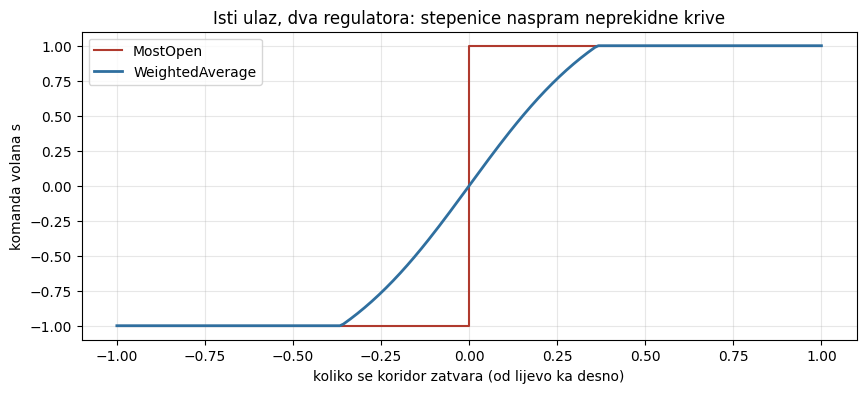

In [13]:
# Koridor koji se postepeno zatvara sa jedne strane pa sa druge.
ts = np.linspace(-1, 1, 200)
cmd_mo, cmd_wa = [], []
for t in ts:
    d = np.clip(0.55 + 0.45 * np.tanh((angles / 30.0) * t), 0, 1)
    cmd_mo.append(most_open(d, angles, STEER_MAX_DEG))
    cmd_wa.append(weighted_average(d, angles, STEER_MAX_DEG))

plt.figure(figsize=(10, 4))
plt.step(ts, cmd_mo, where="mid", label="MostOpen", color="#b03a2e")
plt.plot(ts, cmd_wa, label="WeightedAverage", color="#2f6f9f", linewidth=2)
plt.xlabel("koliko se koridor zatvara (od lijevo ka desno)")
plt.ylabel("komanda volana s")
plt.title("Isti ulaz, dva regulatora: stepenice naspram neprekidne krive")
plt.legend()
plt.show()

Lijevi regulator skače po stepenicama, desni klizi. To je cijela razlika između njih, i ona je
dovoljna da jedan završi **34 od 34** kruga a drugi **0 od 102**.

## 3.3 Brzina se izvodi, ne bira

Dvije relacije, nijedna podešena rukom:

$$
v_{\text{prianjanje}} = \sqrt{a\,R},
\qquad
v_{\text{kočenje}} = \sqrt{2\,a\,d}.
$$

Prva je granica bočnog ubrzanja u krivini poluprečnika $R$, druga je standardna relacija zaustavnog
puta na udaljenosti $d$.

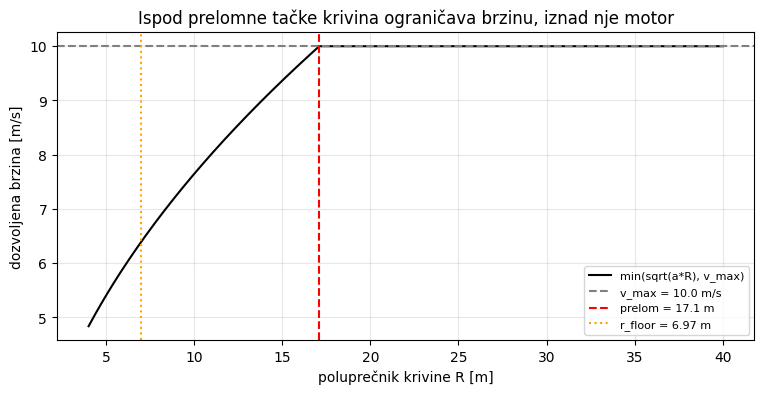

prelomna tacka: 17.1 m
u najostrijoj dozvoljenoj krivini (6.97 m) auto smije 6.39 m/s


In [14]:
A_LAT = 5.85     # m/s^2, iz profila vozila
V_MAX = 10.0     # m/s

radii = np.linspace(4, 40, 300)
v_grip = np.sqrt(A_LAT * radii)

plt.figure(figsize=(9, 4))
plt.plot(radii, np.minimum(v_grip, V_MAX), color="black", label="min(sqrt(a*R), v_max)")
plt.axhline(V_MAX, color="gray", linestyle="--", label=f"v_max = {V_MAX} m/s")
crossover = V_MAX ** 2 / A_LAT
plt.axvline(crossover, color="red", linestyle="--", label=f"prelom = {crossover:.1f} m")
plt.axvline(PROFILE.r_floor_m, color="orange", linestyle=":", label=f"r_floor = {PROFILE.r_floor_m:.2f} m")
plt.xlabel("poluprečnik krivine R [m]")
plt.ylabel("dozvoljena brzina [m/s]")
plt.title("Ispod prelomne tačke krivina ograničava brzinu, iznad nje motor")
plt.legend(fontsize=8)
plt.show()

print(f"prelomna tacka: {crossover:.1f} m")
print(f"u najostrijoj dozvoljenoj krivini ({PROFILE.r_floor_m:.2f} m) auto smije "
      f"{math.sqrt(A_LAT * PROFILE.r_floor_m):.2f} m/s")

# Sekcija 4 - Šta uči PPO

PPO (*Proximal Policy Optimization*) je **on-policy** algoritam: uči iz onoga što je trenutna
politika upravo odvozila, pa to baci i vozi ponovo. Politika je neuronska mreža koja iz
observacije daje akciju.

**Observacija ima 19 brojeva**: 13 udaljenosti zraka preko 180 stepeni, plus šest vrijednosti o
stanju vozila. Ni jedan od njih ne govori gdje je staza, samo šta senzori vide.

**Akcija ima 2 broja**: volan i gas, oba neprekidna.

Ono što se stvarno projektuje nije mreža nego **nagrada**. Tabela je fiksirana u DESIGN §4.5:

In [15]:
reward_table = pd.DataFrame([
    ("checkpoint", +1.0,   "po markeru, 24 markera je krug"),
    ("wrong_way",  -1.0,   "po okretanju u suprotnom smjeru"),
    ("wall",       -5.0,   "po dodiru zida, i epizoda se prekida"),
    ("step",       -0.001, "po koraku, tjera na kratke epizode"),
    ("speed",      +0.002, "puta normalizovana brzina"),
    ("jerk",       -0.005, "za promjenu volana preko praga 0.55"),
], columns=["član", "vrijednost", "znači"])
reward_table

,član,vrijednost,znači
0,checkpoint,1.000,"po markeru, 24 markera je krug"
1,wrong_way,-1.000,po okretanju u suprotnom smjeru
2,wall,-5.000,"po dodiru zida, i epizoda se prekida"
3,step,-0.001,"po koraku, tjera na kratke epizode"
4,speed,0.002,puta normalizovana brzina
5,jerk,-0.005,za promjenu volana preko praga 0.55


## 4.1 Zašto je nagrada za brzinu tako mala

Ovo je aritmetika protiv **farmanja**: ako se vožnja u krug isplati više nego prolazak kroz
markere, agent će naučiti da se vrti umjesto da vozi.

Uslov je da ukupna zarada od brzine kroz cijelu epizodu ostane ispod vrijednosti trećine kruga:

$$
(\text{speed} - |\text{step}|) \times 6000 < \frac{24}{3}
\quad\Longrightarrow\quad
\text{speed} < 0.002333.
$$

In [16]:
MAX_STEPS = 6000
step_cost = 0.001
bound = (24 / 3) / MAX_STEPS + step_cost
print(f"granica za nagradu brzine: {bound:.6f}")
print(f"postavljena vrijednost:    0.002000   ->  {'unutar granice' if 0.002 < bound else 'PREKO'}")

granica za nagradu brzine: 0.002333
postavljena vrijednost:    0.002000   ->  unutar granice


## 4.2 Krive treninga kao podatak

Krive se **ne gledaju kao slika nego kao podatak**: destilovani CSV po runu se commituje, pa je
svaki grafikon ovdje reproduktivan.

Ključna stvar koju treba vidjeti nije ukupna nagrada nego **koji član se pomjerio**. Ukupna
nagrada koja luta ne kaže ništa sama po sebi.

run: ppo_car_009_bc | koraka: 5000000


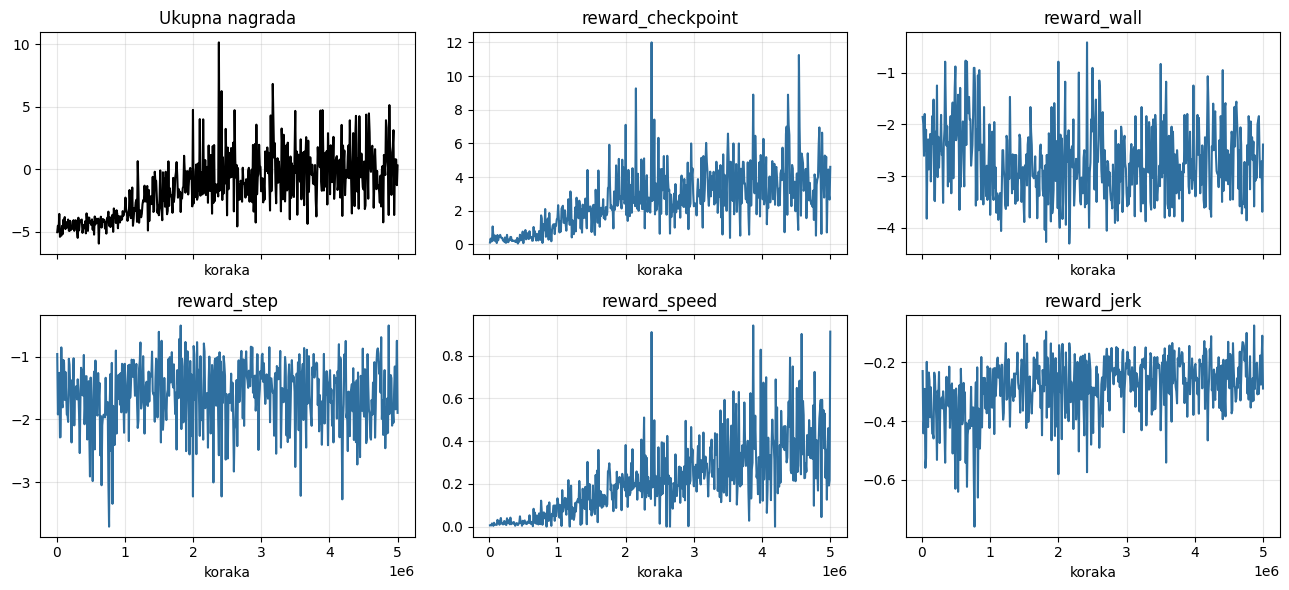

In [17]:
curves = pd.read_csv(REPO_ROOT / "results" / "rl" / "curves" / "ppo_car_009_bc.csv")
print("run:", curves["run_id"].iloc[0], "| koraka:", int(curves["step"].max()))

terms = ["reward_checkpoint", "reward_wall", "reward_step", "reward_speed", "reward_jerk"]
fig, ax = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
ax = ax.ravel()

ax[0].plot(curves["step"], curves["cumulative_reward"], color="black")
ax[0].set_title("Ukupna nagrada")

for a, term in zip(ax[1:], terms):
    a.plot(curves["step"], curves[term], color="#2f6f9f")
    a.set_title(term)

for a in ax:
    a.set_xlabel("koraka")
plt.tight_layout()
plt.show()

## 4.3 Šta je zapravo riješilo M3

M3 je pao **tri puta** prije nego što je prošao. Feature-i 006, 007 i 008 su mijenjali tabelu
nagrade, i dva od njih su oslobodila ono što su mijenjali: problem nije bio u nagradi.

Ono što je pomjerilo milestone je **behavioral cloning zagrijavanje**: agent prvo gleda snimke
skriptiranog vozača, pa tek onda uči sam. Nijedna težina u tabeli nagrade nije dirana.

Uporedimo run bez zagrijavanja i sa njim, na istoj osi.

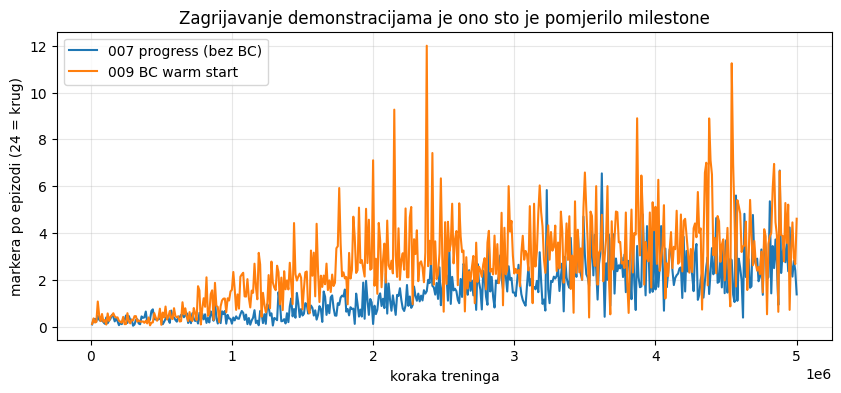

In [18]:
runs = {
    "007 progress (bez BC)": "ppo_car_007_progress.csv",
    "009 BC warm start":     "ppo_car_009_bc.csv",
}

plt.figure(figsize=(10, 4))
for label, fname in runs.items():
    c = pd.read_csv(REPO_ROOT / "results" / "rl" / "curves" / fname)
    plt.plot(c["step"], c["markers_per_episode"], label=label)
plt.xlabel("koraka treninga")
plt.ylabel("markera po epizodi (24 = krug)")
plt.title("Zagrijavanje demonstracijama je ono sto je pomjerilo milestone")
plt.legend()
plt.show()

# Sekcija 5 - Čime se poredi

Poređenje se izvodi **statistički, ne na oko**. Tri instrumenta, svaki za svoje pitanje.

## 5.1 Primarna osa: glatkoća

Mjeri se raspodjela $|\Delta \text{steering}|$ između uzastopnih uzoraka, dvouzoračnim
**Kolmogorov-Smirnov** testom:

$$
D = \sup_x \left| F_{\text{model}}(x) - F_{\text{čovjek}}(x) \right|.
$$

$D$ je **ujedno i veličina efekta**, jer je to najveći razmak između dvije empirijske raspodjele
na skali od 0 do 1, nezavisno od veličine uzorka. To je bitno, jer na 30.000 uzoraka p-vrijednost
odbacuje skoro sve, pa sama po sebi ne nosi informaciju.

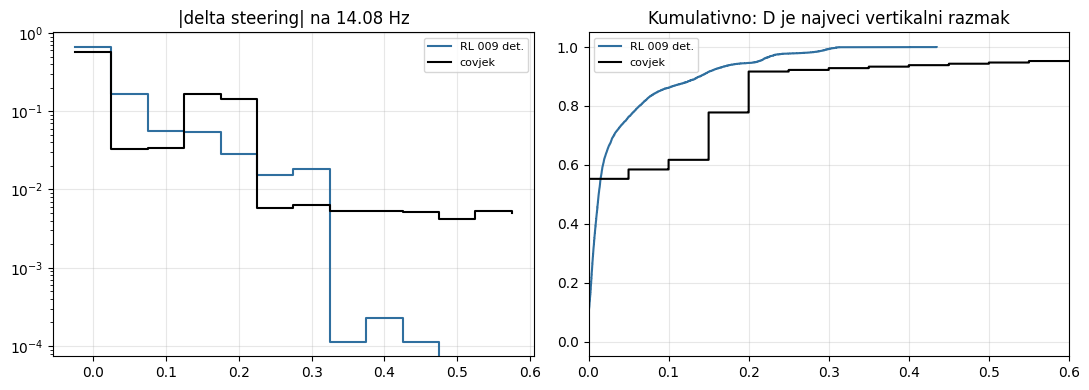

In [19]:
from python.eda.intervals import wilson
from python.m5 import columns as m5

COMPARISON = REPO_ROOT / "results" / "comparison"
if COMPARISON.exists():
    human = m5.human_column(REPO_ROOT)
    rl = m5.rl_column(REPO_ROOT, "ppo_car_009_bc", "deterministic")

    fig, ax = plt.subplots(1, 2)
    edges = np.arange(-0.025, 0.626, 0.05)
    for col, color, label in ((rl, "#2f6f9f", "RL 009 det."), (human, "black", "covjek")):
        counts, _ = np.histogram(col.abs_delta_steering, bins=edges)
        ax[0].step(edges[:-1], counts / counts.sum(), where="post", color=color, label=label)
    ax[0].set_yscale("log")
    ax[0].set_title("|delta steering| na 14.08 Hz")
    ax[0].legend(fontsize=8)

    for col, color, label in ((rl, "#2f6f9f", "RL 009 det."), (human, "black", "covjek")):
        v = np.sort(col.abs_delta_steering)
        ax[1].step(v, np.arange(1, v.size + 1) / v.size, where="post", color=color, label=label)
    ax[1].set_xlim(0, 0.6)
    ax[1].set_title("Kumulativno: D je najveci vertikalni razmak")
    ax[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("results/comparison/ nije generisan u ovom checkoutu")

## 5.2 Sekundarna osa: nivo volana

Ljudski volan sjedi na **rešetci od 41 tačke**, korakom 0.05. Tu je KS pogrešan instrument, jer
pretpostavlja neprekidne podatke, pa se koristi KL divergencija i $\chi^2$ test homogenosti:

$$
D_{\mathrm{KL}}(P \,\|\, Q) = \sum_{\ell} P(\ell) \log \frac{P(\ell)}{Q(\ell)},
\qquad
\chi^2 = \sum_{\ell} \frac{(O_\ell - E_\ell)^2}{E_\ell}.
$$

Svakoj kanti se dodaje $\varepsilon = 10^{-9}$, jer je KL **beskonačan** tamo gdje referenca ima
nultu masu. Takvih nivoa stvarno ima: track1 nikad ne proizvede 0.95.

In [20]:
from python.eda import lattice

levels = lattice.levels()
print("rešetka:", levels.size, "tačaka, od", levels.min(), "do", levels.max(),
      "korakom", round(float(levels[1] - levels[0]), 4))

# KL bez i sa izglađivanjem, na primjeru gdje referenca ima nulu.
p = np.array([0.5, 0.3, 0.2, 0.0])
q = np.array([0.4, 0.3, 0.2, 0.1])
with np.errstate(divide="ignore", invalid="ignore"):
    naive = np.sum(np.where(q > 0, p * np.log(p / np.where(q > 0, q, 1)), np.inf))
print("KL(q || p) kada p ima nulu tamo gdje q nema:", "beskonacno")
print("zato se dodaje epsilon = 1e-9 prije normalizacije")

rešetka: 41 tačaka, od -1.0 do 1.0 korakom 0.05
KL(q || p) kada p ima nulu tamo gdje q nema: beskonacno
zato se dodaje epsilon = 1e-9 prije normalizacije


## 5.3 Stope se nikad ne navode bez intervala

Ovo je najlakša greška u cijelom projektu. "100 posto" na deset runova i "100 posto" na trideset
tri runa **nisu isti rezultat**, a gola procenta to skriva.

Normalna aproksimacija na $\hat p = 1$ daje interval širine **nula**, što tvrdi sigurnost iz
konačnog uzorka. Zato se koristi **Wilsonov** interval:

$$
\frac{\hat p + \dfrac{z^2}{2n} \;\pm\; z \sqrt{\dfrac{\hat p(1-\hat p)}{n} + \dfrac{z^2}{4n^2}}}
{1 + \dfrac{z^2}{n}}.
$$

In [21]:
from python.eda.intervals import wald, wilson

for k, n, opis in ((10, 10, "izdvojenih 10 staza"), (33, 33, "generalizacija, 33 staze"),
                   (31, 34, "hipoteticki: 3 pada od 34")):
    w = wilson(k, n)
    v = wald(k, n)
    print(f"{opis:32s}  Wilson {w}   |  normalna aproks. "
          f"[{100*v.low:.1f}, {100*v.high:.1f}]")

izdvojenih 10 staza               Wilson 10/10 = 100.0% [72.2, 100.0]   |  normalna aproks. [100.0, 100.0]
generalizacija, 33 staze          Wilson 33/33 = 100.0% [89.6, 100.0]   |  normalna aproks. [100.0, 100.0]
hipoteticki: 3 pada od 34         Wilson 31/34 = 91.2% [77.0, 97.0]   |  normalna aproks. [81.6, 100.0]


Prva dva reda su oba **100 posto**, a intervali im se bitno razlikuju: deset savršenih runova je
saglasno sa politikom koja pada na jednoj stazi od četiri, a trideset tri nisu.

Treći red je razlog zašto se poređenje radi **protiv intervala**: pad od tri runa od trideset
četiri i dalje ima interval koji se preklapa sa savršenih deset, pa **ne bi bio dokaz** da je
generalizacija pala.

---

# Šta ovaj notebook ne pokriva

- **Trening se ovdje ne pokreće.** PPO traži Unity i `mlagents-learn`, i traje satima. Ovdje se
  gledaju krive koje su ti runovi već proizveli.
- **BC model se ovdje ne uči.** Za to treba `.venv-bc` i torch, i opisano je u `README.md`.
- **Ovo nije zamjena za DESIGN.md.** Odluke i njihovi razlozi su tamo; ovdje su formule i grafovi.

Puni rezultati poređenja: [`results/comparison/m5_comparison.md`](../../results/comparison/m5_comparison.md).
Dnevnik svih runova, uključujući neuspjele: [`results/EXPERIMENTS.md`](../../results/EXPERIMENTS.md).